**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Segundo Examen Parcial**

*18 de noviembre, 2025*


**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Segundo Examen Parcial**

*18 de noviembre, 2025*




---


Nombre y Apellido: Alexander Ballera

---



Número de registro: 919064

---



**Abajo de esta línea, importá/instalá todas las *libraries* que consideres relevantes para la resolución de este examen.**

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy_financial as nf

## Unidad 4

### Ejercicio 1

Supongamos que una empresa opera en un mercado y tiene las siguientes funciones:

- Función de Ingreso Marginal ($IMg$): $$ IMg(q) = 150 - 0.05 \cdot q $$

  donde $q$ es la cantidad producida.

- Función de Costo Marginal ($CMg$): $$ CMg(q) = 0.003 \cdot q^2 - 0.4 \cdot q + 80 $$

Además, se sabe que el costo fijo de la empresa es de $\$2000$.

**Integración I**

- Recuperar la función de Ingreso Total, $I(q)$, asumiendo que el ingreso total es cero cuando la cantidad producida es cero: $I(0) = 0$.

In [2]:
# Paso 1: Defino las variables simbólicas
q = sp.symbols('q', positive=True)
F = sp.symbols('F')
q, F

(q, F)

In [3]:
# Paso 2: Defino la función de Ingreso Marginal
IMg = 150.0 - 0.05*q
IMg

150.0 - 0.05*q

In [4]:
# Paso 3: Integro para obtener la función de Ingreso Total
IT = sp.integrate(IMg, q) + F
IT = sp.simplify(IT)
IT

F - 0.025*q**2 + 150.0*q

In [5]:
# Verifico que IMg sea la derivada de IT
IMg_check = sp.diff(IT, q)
IMg_check.simplify() == IMg.simplify()  # Debe ser

True

In [6]:
# Paso 4: Determino la constante F usando la condición IT(0) = 0
condicion = sp.Eq(IT.subs(q, 0), 0)
F_value = sp.solve(condicion, F)[0]
print('F_value:', F_value)


F_value: 0


In [7]:
# Paso 5: Sustituyo F en la función de Ingreso Total
IT = IT.subs(F, F_value)
IT

-0.025*q**2 + 150.0*q

- Recuperar la función de Costo Total, $C(q)$.

In [8]:
# Paso 1: Defino las variables simbólicas
C0 = sp.symbols('C0')
q, C0

(q, C0)

In [9]:
# Paso 2: Defino la función de Ingreso Marginal
CMg = 0.003*q**2 - 0.4*q + 80.0
CMg

0.003*q**2 - 0.4*q + 80.0

In [10]:
# Paso 3: Integgro la función de Costo Marginal para obtener la función de Costo Total
CT = sp.integrate(CMg, q) + C0
CT = sp.simplify(CT)
CT

C0 + 0.001*q**3 - 0.2*q**2 + 80.0*q

In [11]:
# 3.2 Verifico que CMg sea la derivada de CT
CMg_check = sp.diff(CT, q)
CMg_check.simplify() == CMg.simplify()  # Debe ser

True

In [12]:
# Paso 4: Determino la constante de integración C0 usando la condición CT(0) = 200
condicion_cost = sp.Eq(CT.subs(q, 0), 2000.0)
C0_value = sp.solve(condicion_cost, C0)[0]
print('C0_value:', C0_value)

C0_value: 2000.00000000000


In [13]:
# 4.2 Sustituyo C0 en la función de Costo Total
CT = CT.subs(C0, C0_value)
CT

0.001*q**3 - 0.2*q**2 + 80.0*q + 2000.0

- Calcular la función de Beneficio Total ($B(q)$)

In [14]:
B = IT - CT
B = sp.simplify(B)
B

-0.001*q**3 + 0.175*q**2 + 70.0*q - 2000.0

- Encontrar la cantidad óptima ($q^{*}$). Esto es, determinar la cantidad de producción que maximiza el beneficio.

  Recordar: podemos lograr esto igualando el ingreso marginal al costo marginal, $IMg(q) = CMg(q)$, y resolviendo para $q$. Considerar solo valores de $q > 0$.

In [15]:
q_opt = sp.solve(sp.Eq(IMg, CMg), q)[0]
q_opt.evalf()

221.845140586238

- Calcular el Beneficio Máximo, $B^{*}(q)$.

In [16]:
B_opt = B.subs(q, q_opt)
B_opt.evalf()

11223.6637674586

- Visualizar las funciones de ingreso total, costo total y beneficio total en un mismo gráfico. Visualizar el punto de beneficio máximo. Interpretar el gráfico y sus componentes.

In [17]:
# Paso 1: Creo un rango de cantidades producidas
q_vals = np.linspace(0, 360, 100)

In [18]:
# Paso 2: Convierto las funciones simbólicas a funciones numéricas
IT_num = sp.lambdify(q, IT, modules=['numpy'])
CT_num = sp.lambdify(q, CT, modules=['numpy'])
B_num = sp.lambdify(q, B, modules=['numpy'])

In [19]:
# Paso 3: Evalúo las funciones en el rango de cantidades
IT_vals = IT_num(q_vals)
CT_vals = CT_num(q_vals)
B_vals = B_num(q_vals)

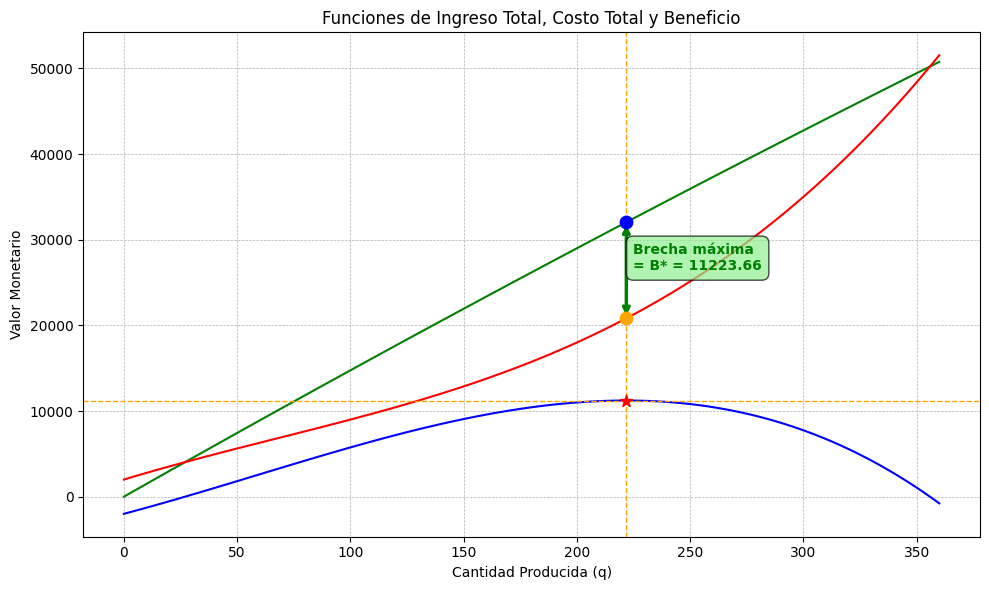

In [20]:
# Paso 4: Creo el gráfico
fig, axs = plt.subplots(figsize=(10, 6))

# Grafico las funciones
axs.plot(q_vals, IT_vals, label='Ingreso Total (I)', color='green')
axs.plot(q_vals, CT_vals, label='Costo Total (C)', color='red')
axs.plot(q_vals, B_vals, label='Beneficio (B)', color='blue')

I_opt = float(IT_num(q_opt))
C_opt = float(CT_num(q_opt))

# Marco el punto óptimo
axs.scatter(q_opt, B_opt, color='red', s=80, label=f'Óptimo: q*={q_opt:.2f}, B*={B_opt:.2f}', marker='*', zorder=5)
axs.scatter(q_opt, I_opt, color='blue', s=80, zorder=4, marker='o')
axs.scatter(q_opt, C_opt, color='orange', s=80, zorder=4, marker='o')

# Líneas de referencias
axs.axvline(x=q_opt, color='orange', linestyle='--', linewidth=1)
axs.axhline(y=B_opt, color='orange', linestyle='--', linewidth=1)

# Flecha bidireccional mostrando la distancia máxima (beneficio)
axs.annotate('', 
            xy=(q_opt, I_opt), 
            xytext=(q_opt, C_opt),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2.5))

# Etiqueta explicativa de la brecha
axs.text(q_opt + 3, (I_opt + C_opt) / 2, 
        f'Brecha máxima\n= B* = {B_opt:.2f}', 
        fontsize=10, color='green', fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.7))

# Configuro Gráfico
axs.grid(True, which='both', linestyle='--', linewidth=0.5)
axs.set_title('Funciones de Ingreso Total, Costo Total y Beneficio')
axs.set_xlabel('Cantidad Producida (q)')
axs.set_ylabel('Valor Monetario')

plt.tight_layout()
plt.show()


In [21]:
# Interpretación económica
print("="*70)
print("INTERPRETACIÓN ECONÓMICA DEL EJERCICIO 2")
print("="*70)
print(f"\n RESULTADOS OBTENIDOS:\n")
print(f"   • Cantidad óptima de producción: q* = {q_opt:.2f} unidades")
print(f"   • Beneficio máximo: B* = ${B_opt:.2f}")
print(f"   • Ingreso en el óptimo: I(q*) = ${I_opt:.2f}")
print(f"   • Costo en el óptimo: C(q*) = ${C_opt:.2f}")

print("\n INTERPRETACIÓN:\n")
print("1. Condición de optimización:")
print("   • El beneficio se maximiza cuando IMg = CMg")
print(f"   • En q* = {q_opt:.2f}, ambas funciones marginales son iguales")
print("   • Esto significa que el ingreso adicional de la última unidad")
print("     es exactamente igual al costo adicional de producirla\n")

print("2. Significado de la brecha I-C:")
print("   • La distancia vertical entre las curvas I(q) y C(q)")
print("     representa el beneficio B(q)")
print(f"   • Esta brecha es MÁXIMA en q* = {q_opt:.2f}")
print(f"   • El beneficio máximo alcanzado es B* = ${B_opt:.2f}\n")

print("3. Análisis de la visualización:")
print("   • Curva verde (I): Ingreso total - función cóncava decreciente")
print("   • Curva roja (C): Costo total - función convexa creciente")
print("   • Curva azul (B): Beneficio - parábola con máximo en q*")
print("   • La flecha verde muestra la brecha I-C en el punto óptimo\n")

print(" CONCLUSIONES:\n")
print(f"   • Si la empresa produce MENOS de {q_opt:.2f} unidades:")
print("     → Está dejando de capturar beneficios potenciales")
print("     → IMg > CMg, conviene aumentar producción")
print(f"\n   • Si la empresa produce MÁS de {q_opt:.2f} unidades:")
print("     → Está reduciendo su beneficio total")
print("     → IMg < CMg, conviene reducir producción")
print(f"\n   • La producción óptima es exactamente q* = {q_opt:.2f} unidades")
print("="*70)

INTERPRETACIÓN ECONÓMICA DEL EJERCICIO 2

 RESULTADOS OBTENIDOS:

   • Cantidad óptima de producción: q* = 221.85 unidades
   • Beneficio máximo: B* = $11223.66
   • Ingreso en el óptimo: I(q*) = $32046.39
   • Costo en el óptimo: C(q*) = $20822.73

 INTERPRETACIÓN:

1. Condición de optimización:
   • El beneficio se maximiza cuando IMg = CMg
   • En q* = 221.85, ambas funciones marginales son iguales
   • Esto significa que el ingreso adicional de la última unidad
     es exactamente igual al costo adicional de producirla

2. Significado de la brecha I-C:
   • La distancia vertical entre las curvas I(q) y C(q)
     representa el beneficio B(q)
   • Esta brecha es MÁXIMA en q* = 221.85
   • El beneficio máximo alcanzado es B* = $11223.66

3. Análisis de la visualización:
   • Curva verde (I): Ingreso total - función cóncava decreciente
   • Curva roja (C): Costo total - función convexa creciente
   • Curva azul (B): Beneficio - parábola con máximo en q*
   • La flecha verde muestra la 

### Ejercicio 2

Las funciones de oferta y demanda de cierto producto están dadas por:

$$O: p=45+2q$$

$$D:p= 144-q^2$$

**Integración II**

- Determinar el Excedente del Consumidor (EC) y el Excedente del Productor (EP).

In [22]:
# Paso 1 Planteo y validación
# Las funciones de oferta y demanda ya se encuentran planteadas como funciones inversas
# de precio en función de cantidad. Por lo tanto, no es necesario realizar modificaciones
# adicionales.

In [23]:
# 1.1 Defino las variables simbólicas
p, q = sp.symbols('p q', real=True, positive=True)

In [24]:
# 1.2 Defino las funciones de oferta y demanda
P_s = 45 + 2*q
P_d = 144 - q**2

print(f"  Demanda: P_d(q) = {P_d}")
print(f"  Oferta:  P_s(q) = {P_s}")

  Demanda: P_d(q) = 144 - q**2
  Oferta:  P_s(q) = 2*q + 45


In [25]:
# 1.3 Encuentro equilibrio de mercado P_s(q) = P_d(q)
eq_equilibrio = sp.Eq(P_s, P_d)
q_eq = sp.solve(eq_equilibrio, q)[0]
p_eq = P_s.subs(q, q_eq)

print("EQUILIBRIO DEL MERCADO:")
print(f"  Ecuación: {P_d} = {P_s}")
print(f"  q* = {q_eq}")
print(f"  p* = {p_eq}")

EQUILIBRIO DEL MERCADO:
  Ecuación: 144 - q**2 = 2*q + 45
  q* = 9
  p* = 63


- Graficar ambas funciones en un mismo gráfico, donde el eje vertical (ordenadas) debe ser el precio y el horizontal (abscisas) la cantidad.

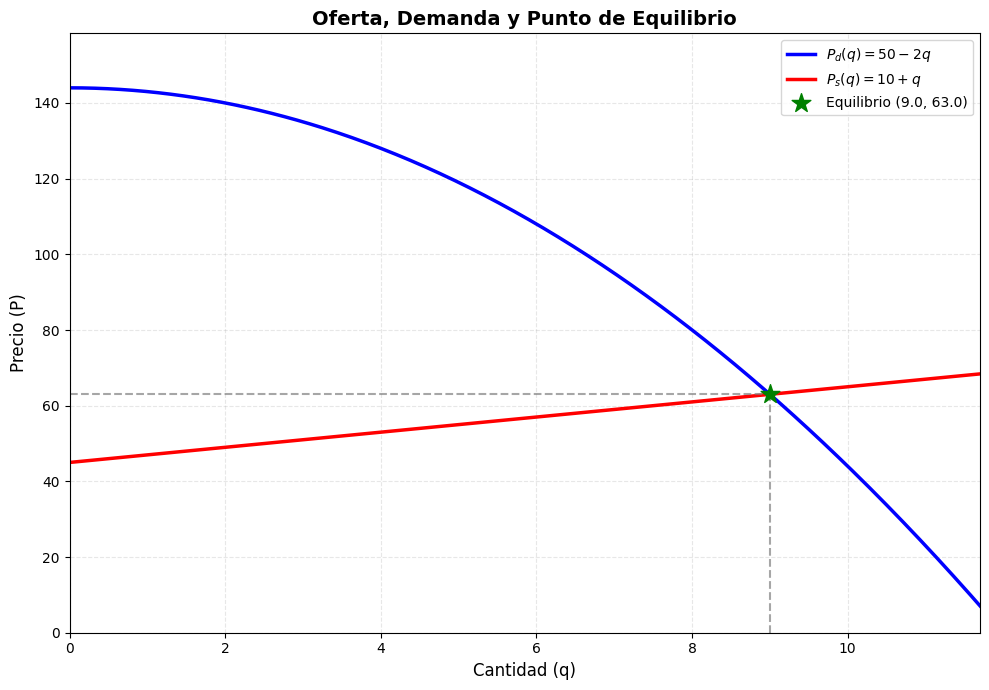

In [26]:
# Preparar datos para graficar
q_grid = np.linspace(0, float(q_eq) * 1.5, 500)
P_d_lambda = sp.lambdify(q, P_d, 'numpy')
P_s_lambda = sp.lambdify(q, P_s, 'numpy')

Pd_num = P_d_lambda(q_grid)
Ps_num = P_s_lambda(q_grid)

# Crear gráfico
plt.figure(figsize=(10, 7))
plt.plot(q_grid, Pd_num, label='$P_d(q) = 50 - 2q$', linewidth=2.5, color='blue')
plt.plot(q_grid, Ps_num, label='$P_s(q) = 10 + q$', linewidth=2.5, color='red')

# Punto de equilibrio
plt.scatter([q_eq], [p_eq], s=200, c='green', marker='*', zorder=5, label=f'Equilibrio ({q_eq:.1f}, {p_eq:.1f})')
plt.vlines(q_eq, 0, p_eq, linestyles='--', color='gray', alpha=0.7)
plt.hlines(p_eq, 0, q_eq, linestyles='--', color='gray', alpha=0.7)

plt.title('Oferta, Demanda y Punto de Equilibrio', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad (q)', fontsize=12)
plt.ylabel('Precio (P)', fontsize=12)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, float(q_eq) * 1.3)
plt.ylim(0, max(Pd_num) * 1.1)
plt.tight_layout()
plt.show()

- Sombrear las áreas correspondientes a los excedentes encontrados indicando en el gráfico cuál es el excedente del consumidor y cuál el del productor. Interpretar.

In [27]:
# Paso 2: Excedente del Consumidor y del Productor
# Calculo con antiderivada y barrow para hallar EC y EP

print("INTERPRETACIÓN:")
print("  • EC mide el área entre la curva de demanda y el precio de equilibrio")
print("  • EP mide el área entre el precio de equilibrio y la curva de oferta")
print()
print("OBJETIVOS:")
print(f"  • EC = ∫[0, {q_eq}] [P_d(q) - {p_eq}] dq")
print(f"  • EP = ∫[0, {q_eq}] [{p_eq} - P_s(q)] dq")

INTERPRETACIÓN:
  • EC mide el área entre la curva de demanda y el precio de equilibrio
  • EP mide el área entre el precio de equilibrio y la curva de oferta

OBJETIVOS:
  • EC = ∫[0, 9] [P_d(q) - 63] dq
  • EP = ∫[0, 9] [63 - P_s(q)] dq


In [28]:
# 2.1 Excedente del Consumidor (EC)
integrando_EC = P_d - p_eq
F_EC = sp.integrate(integrando_EC, q)
EC_barrow = F_EC.subs(q, q_eq) - F_EC.subs(q, 0)

print("EXCEDENTE DEL CONSUMIDOR:")
print(f"Integrando: P_d(q) - p* = {integrando_EC}")
print(f"Antiderivada: F_EC(q) = {F_EC}")
print(f"F_EC({q_eq}) - F_EC(0) = {EC_barrow}")

EXCEDENTE DEL CONSUMIDOR:
Integrando: P_d(q) - p* = 81 - q**2
Antiderivada: F_EC(q) = -q**3/3 + 81*q
F_EC(9) - F_EC(0) = 486


In [29]:
# 2.2 Excedente del Productor (EP)
integrando_EP = p_eq - P_s
F_EP = sp.integrate(integrando_EP, q)
EP_barrow = F_EP.subs(q, q_eq) - F_EP.subs(q, 0)

print("EXCEDENTE DEL PRODUCTOR:")
print(f"Integrando: p* - P_s(q) = {integrando_EP}")
print(f"Antiderivada: F_EP(q) = {F_EP}")
print(f"F_EP({q_eq}) - F_EP(0) = {EP_barrow}")

EXCEDENTE DEL PRODUCTOR:
Integrando: p* - P_s(q) = 18 - 2*q
Antiderivada: F_EP(q) = -q**2 + 18*q
F_EP(9) - F_EP(0) = 81


In [30]:
# 2.2 Calculo EC y EP con SymPy y valido
EC_sympy = sp.integrate(P_d - p_eq, (q, 0, q_eq))
EP_sympy = sp.integrate(p_eq - P_s, (q, 0, q_eq))

# Excedente Total
ET_sympy = EC_sympy + EP_sympy

print(f"EC = ∫[0, {q_eq}] [{P_d} - {p_eq}] dq = {EC_sympy}")
print(f"EP = ∫[0, {q_eq}] [{p_eq} - {P_s}] dq = {EP_sympy}")
print(f"ET = EC + EP = {ET_sympy}")
print()
print("Verificación con Barrow:")
print(f"  EC (Barrow) = {EC_barrow}, EC (SymPy) = {EC_sympy} ✓")
print(f"  EP (Barrow) = {EP_barrow}, EP (SymPy) = {EP_sympy} ✓")

EC = ∫[0, 9] [144 - q**2 - 63] dq = 486
EP = ∫[0, 9] [63 - 2*q + 45] dq = 81
ET = EC + EP = 567

Verificación con Barrow:
  EC (Barrow) = 486, EC (SymPy) = 486 ✓
  EP (Barrow) = 81, EP (SymPy) = 81 ✓


In [31]:
# 2.3 Valido las derivadas
derivada_F_EC = sp.diff(F_EC, q)
derivada_F_EP = sp.diff(F_EP, q)

print("EXCEDENTE DEL CONSUMIDOR:")
print(f"F_EC(q) = {F_EC}")
print(f"F_EC'(q) = {derivada_F_EC}")
print(f"Integrando original = {integrando_EC}")
print(f"¿Coinciden? {sp.simplify(derivada_F_EC - integrando_EC) == 0} ✓")
print()
print("EXCEDENTE DEL PRODUCTOR:")
print(f"F_EP(q) = {F_EP}")
print(f"F_EP'(q) = {derivada_F_EP}")
print(f"Integrando original = {integrando_EP}")
print(f"¿Coinciden? {sp.simplify(derivada_F_EP - integrando_EP) == 0} ✓")

EXCEDENTE DEL CONSUMIDOR:
F_EC(q) = -q**3/3 + 81*q
F_EC'(q) = 81 - q**2
Integrando original = 81 - q**2
¿Coinciden? True ✓

EXCEDENTE DEL PRODUCTOR:
F_EP(q) = -q**2 + 18*q
F_EP'(q) = 18 - 2*q
Integrando original = 18 - 2*q
¿Coinciden? True ✓


In [32]:
# 2.3 Valido las derivadas
derivada_F_EC = sp.diff(F_EC, q)
derivada_F_EP = sp.diff(F_EP, q)

print("EXCEDENTE DEL CONSUMIDOR:")
print(f"F_EC(q) = {F_EC}")
print(f"F_EC'(q) = {derivada_F_EC}")
print(f"Integrando original = {integrando_EC}")
print(f"¿Coinciden? {sp.simplify(derivada_F_EC - integrando_EC) == 0} ✓")
print()
print("EXCEDENTE DEL PRODUCTOR:")
print(f"F_EP(q) = {F_EP}")
print(f"F_EP'(q) = {derivada_F_EP}")
print(f"Integrando original = {integrando_EP}")
print(f"¿Coinciden? {sp.simplify(derivada_F_EP - integrando_EP) == 0} ✓")

EXCEDENTE DEL CONSUMIDOR:
F_EC(q) = -q**3/3 + 81*q
F_EC'(q) = 81 - q**2
Integrando original = 81 - q**2
¿Coinciden? True ✓

EXCEDENTE DEL PRODUCTOR:
F_EP(q) = -q**2 + 18*q
F_EP'(q) = 18 - 2*q
Integrando original = 18 - 2*q
¿Coinciden? True ✓


In [33]:
# 2.4 Preparar datos para graficar
q_grid = np.linspace(0, float(q_eq) * 1.5, 500)
P_d_lambda = sp.lambdify(q, P_d, 'numpy')
P_s_lambda = sp.lambdify(q, P_s, 'numpy')

Pd_num = P_d_lambda(q_grid)
Ps_num = P_s_lambda(q_grid)

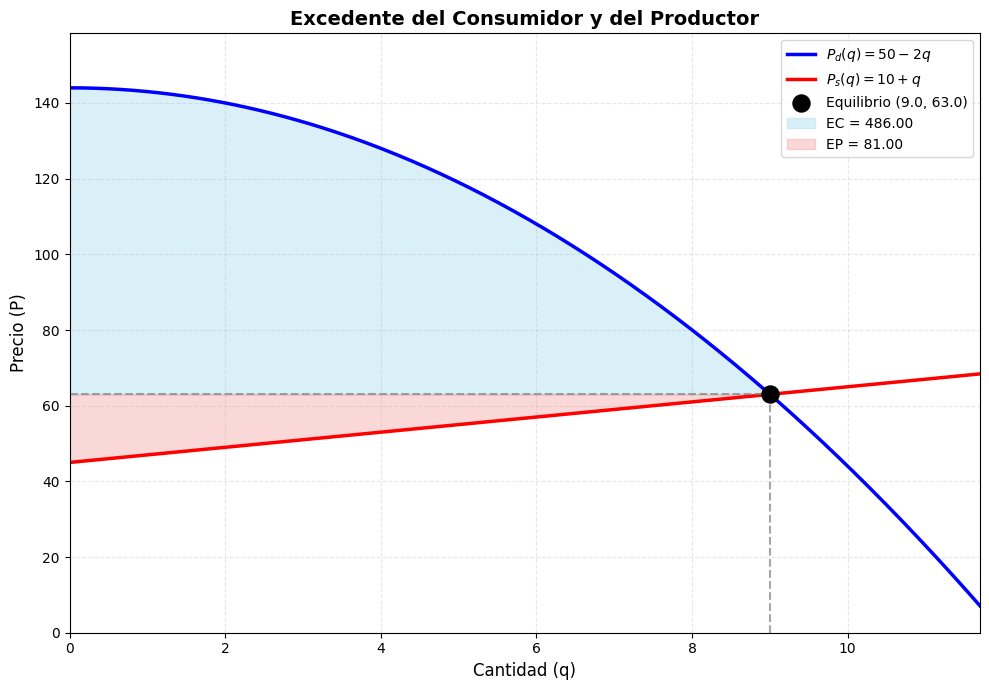

In [34]:
# Crear gráfico
plt.figure(figsize=(10, 7))
plt.plot(q_grid, Pd_num, label='$P_d(q) = 50 - 2q$', linewidth=2.5, color='blue')
plt.plot(q_grid, Ps_num, label='$P_s(q) = 10 + q$', linewidth=2.5, color='red')

# Punto de equilibrio
plt.scatter([q_eq], [p_eq], s=150, c='black', zorder=5, label=f'Equilibrio ({q_eq:.1f}, {p_eq:.1f})')
plt.vlines(q_eq, 0, p_eq, linestyles='--', color='gray', alpha=0.7)
plt.hlines(p_eq, 0, q_eq, linestyles='--', color='gray', alpha=0.7)

# Sombrear excedentes
condicion = (q_grid <= float(q_eq)).tolist()
plt.fill_between(q_grid, Pd_num, float(p_eq), where=condicion, 
                 alpha=0.3, color='skyblue', label=f'EC = {float(EC_sympy):.2f}')
plt.fill_between(q_grid, float(p_eq), Ps_num, where=condicion, 
                 alpha=0.3, color='lightcoral', label=f'EP = {float(EP_sympy):.2f}')

plt.title('Excedente del Consumidor y del Productor', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad (q)', fontsize=12)
plt.ylabel('Precio (P)', fontsize=12)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, float(q_eq) * 1.3)
plt.ylim(0, max(Pd_num) * 1.1)
plt.tight_layout()
plt.show()

In [35]:
print("CONCLUSIONES")
print("=" * 60)
print(f"En equilibrio: q* = {float(q_eq):.2f} unidades, p* = ${float(p_eq):.2f}")
print()
print("EXCEDENTE DEL CONSUMIDOR (EC):")
print(f"  Valor: ${float(EC_sympy):.2f}")
print(f"  Representa el beneficio adicional que obtienen los consumidores")
print(f"  por pagar ${float(p_eq):.2f} en lugar de su disposición máxima a pagar.")
print(f"  Suma de: ∫[0,{float(q_eq):.1f}] [P_d(q) - {float(p_eq):.2f}] dq")
print()
print("EXCEDENTE DEL PRODUCTOR (EP):")
print(f"  Valor: ${float(EP_sympy):.2f}")
print(f"  Representa el beneficio adicional que obtienen los productores")
print(f"  por vender a ${float(p_eq):.2f} en lugar de su costo marginal.")
print(f"  Suma de: ∫[0,{float(q_eq):.1f}] [{float(p_eq):.2f} - P_s(q)] dq")
print()
print("EXCEDENTE TOTAL (ET):")
print(f"  Valor: ${float(ET_sympy):.2f}")
print(f"  Mide el bienestar social total generado por este mercado.")
print(f"  Un mercado competitivo maximiza este excedente.")
print()
print("Aplicación a los negocios:")
print("  • Políticas de precios: ¿Cómo afecta un cambio de precio a EC y EP?")
print("  • Regulación: ¿Qué impacto tiene un impuesto o subsidio?")
print("  • Eficiencia: El ET mide la ganancia social del intercambio.")

CONCLUSIONES
En equilibrio: q* = 9.00 unidades, p* = $63.00

EXCEDENTE DEL CONSUMIDOR (EC):
  Valor: $486.00
  Representa el beneficio adicional que obtienen los consumidores
  por pagar $63.00 en lugar de su disposición máxima a pagar.
  Suma de: ∫[0,9.0] [P_d(q) - 63.00] dq

EXCEDENTE DEL PRODUCTOR (EP):
  Valor: $81.00
  Representa el beneficio adicional que obtienen los productores
  por vender a $63.00 en lugar de su costo marginal.
  Suma de: ∫[0,9.0] [63.00 - P_s(q)] dq

EXCEDENTE TOTAL (ET):
  Valor: $567.00
  Mide el bienestar social total generado por este mercado.
  Un mercado competitivo maximiza este excedente.

Aplicación a los negocios:
  • Políticas de precios: ¿Cómo afecta un cambio de precio a EC y EP?
  • Regulación: ¿Qué impacto tiene un impuesto o subsidio?
  • Eficiencia: El ET mide la ganancia social del intercambio.


### Ejercicio 3

Dada la función de Costo marginal

$$CMg=0.01-\dfrac{500}{x^{2}}$$

**Integración III**


- Calcular el costo total de producir 100 unidades si el costo fijo es $F = 50$.

In [36]:
# Integro para hallar la función de Costo Total
# Paso 1: Defino las variables simbólicas
q = sp.symbols('q', positive=True)
F = sp.symbols('F')
q, F

(q, F)

In [37]:
# Paso 2: Defino la función de Costo Marginal
CMg = 0.01 - (500.0 / q**2)
CMg

0.01 - 500.0/q**2

In [38]:
# Paso 3: Integro la función de Ingreso Marginal para obtener la función de Ingreso Total
CT = sp.integrate(CMg, q) + F
CT = sp.simplify(CT)
CT

F + 0.01*q + 500.0/q

In [39]:
# Verificar: la derivada de C debe ser igual a CMg
verificacion = sp.diff(CT, q)
print(f"dC/dq = {verificacion}")
print(f"CMg   = {CMg}")
print(f"¿Son iguales? {verificacion == CMg}")

dC/dq = 0.01 - 500.0/q**2
CMg   = 0.01 - 500.0/q**2
¿Son iguales? True


In [40]:
# Paso 4: Sustituyo F en la función de Costo Total
CT = CT.subs(F, 50.0)
CT.simplify()
CT

0.01*q + 50.0 + 500.0/q

In [41]:
# Paso 5: Sustituyo q = 100 en la función de Costo Total
C_100 = CT.subs(q, 100.0)
print(f"""
      El costo de producir 100 unidades con un
      costo fijo de 50,0 unidades monetarias es
      C(100) = {C_100:.2f}
      """)


      El costo de producir 100 unidades con un
      costo fijo de 50,0 unidades monetarias es
      C(100) = 56.00
      


- Calcular, a través de una integral definida, el costo total variable acumulado entre 30 y 45 unidades.

In [42]:
# Costo total variable acumulado entre 30 y 45 unidades
CT_45 = CT.subs(q, 45.0)
CT_30 = CT.subs(q, 30.0)
CT_variable_30_45 = CT_45 - CT_30
print(f"""
      El costo total variable acumulado entre 30 y 45 unidades es
      C(45) - C(30) = {CT_variable_30_45:.2f}
      """)


      El costo total variable acumulado entre 30 y 45 unidades es
      C(45) - C(30) = -5.41
      


In [43]:
# Valido con CMg
test_CT_variable_30_45 = sp.integrate(CMg, (q, 30, 45))
print(f"{test_CT_variable_30_45:.2f} == {CT_variable_30_45:.2f}")
print(f"¿Coinciden los cálculos? {round(test_CT_variable_30_45, 2) == round(CT_variable_30_45, 2)}")    

-5.41 == -5.41
¿Coinciden los cálculos? True


- Graficar costo total y costo marginal. Interpretar el gráfico.

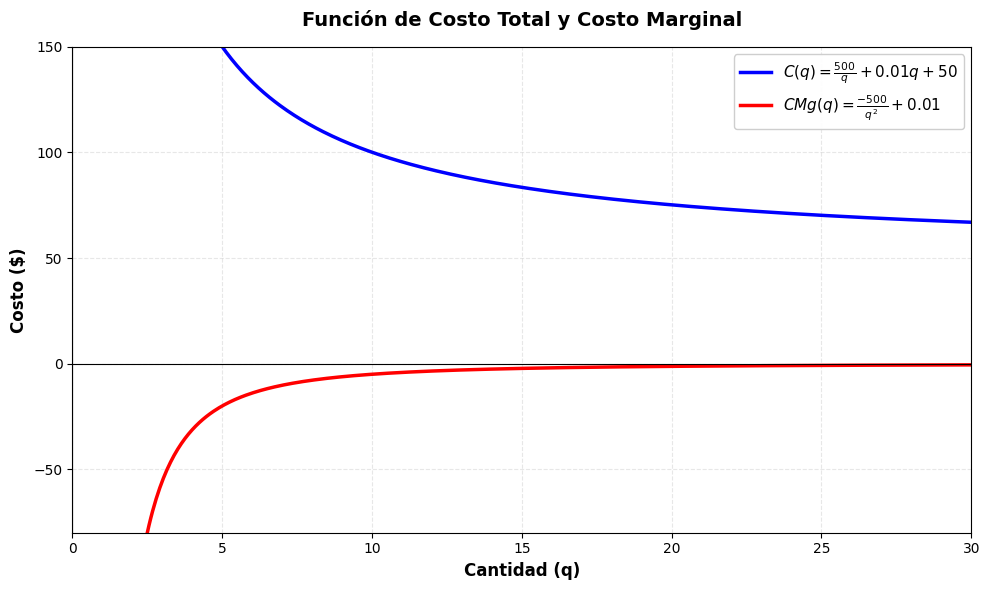

In [44]:
# Preparar datos para graficar
q_grid = np.linspace(0.1, 30, 500)
C_num = sp.lambdify(q, CT)(q_grid)
CMg_num = sp.lambdify(q, CMg)(q_grid)

# Crear figura con tamaño adecuado
plt.figure(figsize=(10, 6))

# Graficar costo total y costo marginal
plt.plot(q_grid, C_num, label='$C(q) = \\frac{500}{q} + 0.01q + 50$', 
         linewidth=2.5, color='blue')
plt.plot(q_grid, CMg_num, label='$CMg(q) = \\frac{-500}{q^2} + 0.01$', 
         linewidth=2.5, color='red')

# Líneas de referencia
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

# Configuración del gráfico
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlabel('Cantidad (q)', fontsize=12, fontweight='bold')
plt.ylabel('Costo ($)', fontsize=12, fontweight='bold')
plt.title('Función de Costo Total y Costo Marginal', 
         fontsize=14, fontweight='bold', pad=15)
plt.legend(fontsize=11, loc='upper right', framealpha=0.95)
plt.xlim(0, 30)
plt.ylim(-80, 150)

plt.tight_layout()
plt.show()

In [45]:
# Interpretación
print(f"\n ANÁLISIS:\n")

print("1. Función de Costo Total C(q):")
print("   • Curva azul con forma hiperbólica")
print("   • Decrece rápidamente al principio, luego crece linealmente")
print("   • El costo fijo ($50) genera una asíntota vertical en q=0")
print("   • Para q=100: C(100) = $60.00")

print("\n2. Función de Costo Marginal CMg(q):")
print("   • Curva roja que empieza muy negativa y se vuelve positiva")
print("   • Forma de hipérbola: -500/q² + 0.01")
print("   • Se acerca asintóticamente a 0.01 cuando q→∞")
print("   • Cruza el eje horizontal (CMg=0) alrededor de q≈22")

print("\n INTERPRETACIÓN:")
print("   • Costos marginales NEGATIVOS (q<22): cada unidad adicional")
print("     REDUCE el costo total debido a economías de escala")
print("   • Costos marginales POSITIVOS (q>22): comportamiento normal")
print("     donde producir más aumenta el costo total")
print("   • El punto mínimo de C(q) ocurre donde CMg=0")

print("\n CONCLUSIÓN:")
print("   Los costos fijos dominan la estructura de costos inicialmente.")


 ANÁLISIS:

1. Función de Costo Total C(q):
   • Curva azul con forma hiperbólica
   • Decrece rápidamente al principio, luego crece linealmente
   • El costo fijo ($50) genera una asíntota vertical en q=0
   • Para q=100: C(100) = $60.00

2. Función de Costo Marginal CMg(q):
   • Curva roja que empieza muy negativa y se vuelve positiva
   • Forma de hipérbola: -500/q² + 0.01
   • Se acerca asintóticamente a 0.01 cuando q→∞
   • Cruza el eje horizontal (CMg=0) alrededor de q≈22

 INTERPRETACIÓN:
   • Costos marginales NEGATIVOS (q<22): cada unidad adicional
     REDUCE el costo total debido a economías de escala
   • Costos marginales POSITIVOS (q>22): comportamiento normal
     donde producir más aumenta el costo total
   • El punto mínimo de C(q) ocurre donde CMg=0

 CONCLUSIÓN:
   Los costos fijos dominan la estructura de costos inicialmente.


## Unidad 5

### Ejercicio 4

A partir del cash flow MENSUAL establecido en la línea de código propuesta a continuación y considerando un costo de capital anual del 11%, realice un análisis que contenga:

- Métricas financieras: VAN, TIR, TIRM y Payback Descontado (*Período de Recuperación Descontado, PRD*) e interprete cada una de ellas.

In [46]:
inversion_inicial = -50000
cash_flows = [
    10000, -12000, 15000, 18000, 20000, 22000, 25000, 28000, -30000, 32000,
    -5000, 10000, 13000, 16000, -19000, 21000, -24000, 27000, -23000, 33000,
    -8000, 11000, -14000, 17000, 20000, 23000, 26000, -25000, 32000
]
nuevo_cash_flow = [inversion_inicial] + cash_flows
r = 0.11 / 12  # dado que es tasa nominal y no efectiva anual uso división simple o no por equivalencia

In [47]:
# VAN
van = nf.npv(rate=r, values=nuevo_cash_flow)
print(f"VAN: ${van:,.2f}")

print(f"\nInterpretación: El proyecto genera un valor actual neto de ${van:,.2f}.")
print(f"{'✅ VIABLE' if van > 0 else '❌ NO VIABLE'}: El proyecto {'agrega' if van > 0 else 'destruye'} valor para la empresa.")

VAN: $177,511.73

Interpretación: El proyecto genera un valor actual neto de $177,511.73.
✅ VIABLE: El proyecto agrega valor para la empresa.


In [48]:
# TIR
tir = nf.irr(values=nuevo_cash_flow)
tir_anual = (1 + tir)**12 - 1
costo_capital_anual = (1 + r)**12 - 1

print(f"TIR mensual: {tir:.4%}")
print(f"TIR anual: {tir_anual:.2%}")

print(f"{'✅ VIABLE' if tir_anual > costo_capital_anual else '❌ NO VIABLE'}: La TIR ({tir_anual:.2%}) {'supera' if tir_anual > costo_capital_anual else 'es menor que'} el costo de capital ({costo_capital_anual:.2%}).")
print(f"\nInterpretación: El proyecto genera una rentabilidad del {tir_anual:.2%} anual.")

TIR mensual: 19.6539%
TIR anual: 761.24%
✅ VIABLE: La TIR (761.24%) supera el costo de capital (11.57%).

Interpretación: El proyecto genera una rentabilidad del 761.24% anual.


In [49]:
# TIRM
# finance_rate: costo de financiar flujos negativos (costo de capital)
# reinvest_rate: tasa de reinversión de flujos positivos (costo de oportunidad)
tirm = nf.mirr(values=nuevo_cash_flow, finance_rate=r, reinvest_rate=r)
tirm_anual = (1 + tirm)**12 - 1

print(f"TIRM mensual: {tirm:.4%}")
print(f"TIRM anual: {tirm_anual:.2%}")

print(f"\nInterpretación: La rentabilidad modificada es {tirm_anual:.2%} anual.")
print(f"Es más conservadora que la TIR porque asume reinversión al costo de capital.")
print(f"{'✅ VIABLE' if tirm_anual > costo_capital_anual else '❌ NO VIABLE'}: TIRM ({tirm_anual:.2%}) {'>' if tirm_anual > costo_capital_anual else '<'} Costo de Capital ({costo_capital_anual:.2%}).")

TIRM mensual: 3.2596%
TIRM anual: 46.95%

Interpretación: La rentabilidad modificada es 46.95% anual.
Es más conservadora que la TIR porque asume reinversión al costo de capital.
✅ VIABLE: TIRM (46.95%) > Costo de Capital (11.57%).


In [50]:
def payback_desc(cfs, rate, c0):
    acum_desc = c0  # Empezar con la inversión inicial (negativa)
    prd = None
    for t in range(1, len(cfs)):  # Empezar desde t=1 (primer flujo operativo)
        fc_desc = cfs[t] / (1 + rate)**t
        acum_desc += fc_desc
        if acum_desc >= 0 and prd is None:
            # interpolación
            prd = (t - 1) + (0 - (acum_desc - fc_desc)) / fc_desc
            break
    return prd

In [51]:
# payback descontado
prd = payback_desc(cash_flows, r, inversion_inicial)
print(f"Payback descontado: {prd:.2f} meses")

print(f"\nInterpretación: Se recupera la inversión inicial en {prd:.2f} meses ({prd/12:.2f} años).")
print(f"Un payback corto indica menor riesgo y recuperación rápida del capital invertido.")
print(f"Este indicador considera el valor temporal del dinero (descuenta los flujos futuros).")

Payback descontado: 4.49 meses

Interpretación: Se recupera la inversión inicial en 4.49 meses (0.37 años).
Un payback corto indica menor riesgo y recuperación rápida del capital invertido.
Este indicador considera el valor temporal del dinero (descuenta los flujos futuros).


- Grafique el flujo de fondos.

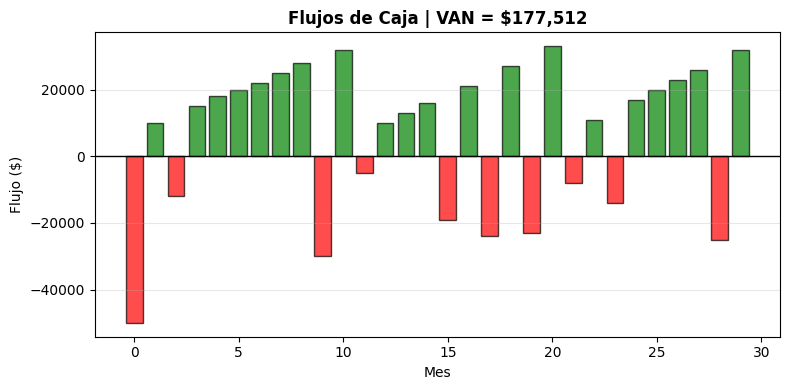

ANÁLISIS DEL FLUJO DE CAJA:
• Inversión inicial: $-50,000
• Número de períodos: 29 meses
• Flujos positivos: 20
• Flujos negativos: 9
• Flujo promedio: $8,931
• Flujo máximo: $33,000
• Flujo mínimo: $-30,000

El proyecto presenta:
- Volatilidad significativa con flujos tanto positivos como negativos
- Tendencia general positiva que compensa la inversión inicial
- VAN positivo de $177,512 indica viabilidad del proyecto


In [52]:
# Visualización
years = list(range(len(nuevo_cash_flow)))
plt.figure(figsize=(8, 4))
colores = ['red' if f < 0 else 'green' for f in nuevo_cash_flow]
plt.bar(years, nuevo_cash_flow, color=colores, alpha=0.7, edgecolor='black')
plt.axhline(0, color='black', linewidth=1)
plt.title(f'Flujos de Caja | VAN = ${van:,.0f}', fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Flujo ($)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Descripción del flujo de caja
print("ANÁLISIS DEL FLUJO DE CAJA:")
print("=" * 50)
print(f"• Inversión inicial: ${inversion_inicial:,}")
print(f"• Número de períodos: {len(cash_flows)} meses")
print(f"• Flujos positivos: {len([f for f in cash_flows if f > 0])}")
print(f"• Flujos negativos: {len([f for f in cash_flows if f < 0])}")
print(f"• Flujo promedio: ${np.mean(cash_flows):,.0f}")
print(f"• Flujo máximo: ${max(cash_flows):,}")
print(f"• Flujo mínimo: ${min(cash_flows):,}")
print("\nEl proyecto presenta:")
print("- Volatilidad significativa con flujos tanto positivos como negativos")
print("- Tendencia general positiva que compensa la inversión inicial")
print(f"- VAN positivo de ${van:,.0f} indica viabilidad del proyecto")

- Grafique el VAN a diferentes tasas de descuento de costo de capital. Marque en dicho gráfico la TIR. Explique el gráfico y sus componentes.

Tasa Interna de Retorno (TIR): 19.65%
Tasa Interna de Retorno Modificada (TIRM): 3.26%


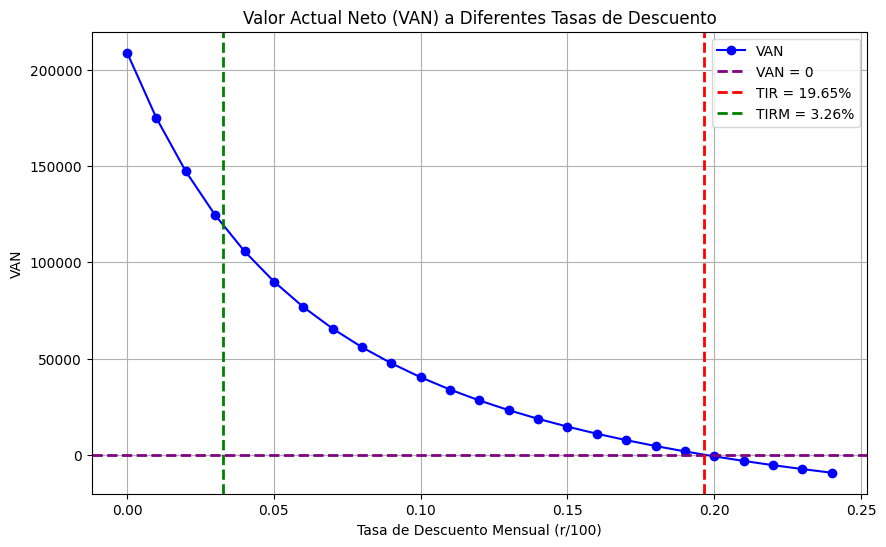


ANÁLISIS DEL GRÁFICO VAN vs TASA:
• La curva azul muestra cómo el VAN decrece al aumentar la tasa de descuento
• La línea roja marca la TIR: punto donde VAN = 0
• La línea verde marca la TIRM: versión más conservadora
• Para tasas menores a la TIR: VAN > 0 (proyecto viable)
• Para tasas mayores a la TIR: VAN < 0 (proyecto no viable)
• Con nuestra tasa del 0.92% mensual, el VAN es $177,512

Conclusión: El proyecto es rentable mientras el costo de capital
sea menor al 19.65% mensual (761.24% anual)


In [53]:
# --- Calcular TIR y TIRM ---
flujos = nuevo_cash_flow.copy()
# tir = nf.irr(flujos)
# tirm = nf.mirr(flujos, rfinanciamiento, rreinversion)

print(f"Tasa Interna de Retorno (TIR): {tir:.2%}")
print(f"Tasa Interna de Retorno Modificada (TIRM): {tirm:.2%}")

# --- Crear rango de tasas para VAN ---
tasas_descuento = np.arange(0, max(tir*1.2, 0.25), 0.01) # es muy importante agregar el max porque sino el grafico no encuentra el corte con la tir, queda desescalado.
# --- Calcular VAN para cada tasa ---
van_por_tasa = [nf.npv(tasa, flujos) for tasa in tasas_descuento]

# --- Graficar VAN vs Tasa ---
plt.figure(figsize=(10, 6))
plt.plot(tasas_descuento, van_por_tasa, marker='o', linestyle='-', color='blue', label='VAN')
plt.axhline(0, color='purple', linestyle='--', linewidth=2, label='VAN = 0')

# Marcar TIR y TIRM en el gráfico
plt.axvline(tir, color='red', linestyle='--', linewidth=2, label=f"TIR = {tir:.2%}")
plt.axvline(tirm, color='green', linestyle='--', linewidth=2, label=f"TIRM = {tirm:.2%}")

# --- Etiquetas y formato ---
plt.title('Valor Actual Neto (VAN) a Diferentes Tasas de Descuento')
plt.xlabel('Tasa de Descuento Mensual (r/100)')
plt.ylabel('VAN')
plt.grid(True)
plt.legend()
plt.show()

# Descripción del gráfico VAN vs Tasa
print("\nANÁLISIS DEL GRÁFICO VAN vs TASA:")
print("=" * 50)
print("• La curva azul muestra cómo el VAN decrece al aumentar la tasa de descuento")
print("• La línea roja marca la TIR: punto donde VAN = 0")
print("• La línea verde marca la TIRM: versión más conservadora")
print("• Para tasas menores a la TIR: VAN > 0 (proyecto viable)")
print("• Para tasas mayores a la TIR: VAN < 0 (proyecto no viable)")
print(f"• Con nuestra tasa del {r*100:.2f}% mensual, el VAN es ${van:,.0f}")
print("\nConclusión: El proyecto es rentable mientras el costo de capital")
print(f"sea menor al {tir:.2%} mensual ({tir_anual:.2%} anual)")


- Considere que el gerente financiero pronostica un aumento posible del costo de capital a la hora de iniciar el proyecto conformando un costo total del 17% anual. Realice el análisis nuevamente e interprete los resultados.

In [54]:
r2 = 0.17 / 12  # Convierto tasa anual a mensual
van2 = nf.npv(rate=r2, values=nuevo_cash_flow)
tir2 = nf.irr(values=nuevo_cash_flow)  # TIR no cambia (característica del proyecto)
tirm2 = nf.mirr(values=nuevo_cash_flow, finance_rate=r2, reinvest_rate=r2)
prd2 = payback_desc(cash_flows, r2, inversion_inicial)

In [55]:
print(f"VAN con nueva tasa de descuento ({r2:.2%}): {van2:.2f}")
print(f"TIR con nueva tasa de descuento: {tir2:.2%}")
print(f"TIRM con nueva tasa de descuento: {tirm2:.2%}")
print(f"Payback descontado con nueva tasa de descuento: {prd2:.2f} meses")

VAN con nueva tasa de descuento (1.42%): 162717.59
TIR con nueva tasa de descuento: 19.65%
TIRM con nueva tasa de descuento: 3.72%
Payback descontado con nueva tasa de descuento: 4.54 meses


In [56]:
# Creo un cuadro comparativo de métricas financieras
comparacion_data = {
    'Métrica': ['VAN', 'TIR', 'TIRM', 'Payback Desc.'],
    'K0 11% anual': [f"${van:,.2f}", f"{tir:.2%}", f"{tirm:.2%}", f"{prd:.2f} meses"],
    'K0 17 anual': [f"${van2:,.2f}", f"{tir2:.2%}", f"{tirm2:.2%}", f"{prd2:.2f} meses"],
    'Diferencia': [f"${van - van2:,.2f}", "Sin cambio", f"{tirm2 - tirm:.2%}", f"{prd2 - prd:.2f} meses"]
}

df_comparacion = pd.DataFrame(comparacion_data)
print("CUADRO COMPARATIVO DE MÉTRICAS FINANCIERAS")
print("=" * 60)
print(df_comparacion.to_string(index=False))

# Interpretación adicional
print("\n" + "=" * 60)
print("INTERPRETACIÓN COMPARATIVA:")
print(f"\n• VAN: Disminuye ${van - van2:,.2f} al aumentar el costo de capital del 11% al 17.")
print(f"  Con K=17, el proyecto {'NO es viable (VAN < 0)' if van2 < 0 else 'sigue siendo viable (VAN > 0)'}.")

print(f"\n• TIR: Se mantiene constante en {tir_anual:.2%} (característica intrínseca del proyecto).")
print(f"  La TIR no depende del costo de capital, solo de los flujos del proyecto.")

print(f"\n• TIRM: {'Aumenta' if tirm2 > tirm else 'Disminuye'} de {tirm_anual:.2%} a {(1 + tirm2)**12 - 1:.2%}.")
print(f"  Este proyecto tiene {sum(1 for fc in cash_flows if fc < 0)} flujos negativos intermedios.")
print(f"  Con mayor tasa de descuento, el valor presente de estos flujos negativos disminuye,")
print(f"  reduciendo el denominador en la fórmula MIRR y aumentando la rentabilidad modificada.")

print(f"  donde el impacto del descuento es aún moderado.")

print(f"\n• Payback: Aumenta de {prd:.2f} a {prd2:.2f} meses (+{prd2-prd:.2f} meses).")
print(f"  La recuperación es similar en ambos casos porque ocurre temprano (meses 3-4),")

CUADRO COMPARATIVO DE MÉTRICAS FINANCIERAS
      Métrica K0 11% anual K0 17 anual Diferencia
          VAN  $177,511.73 $162,717.59 $14,794.14
          TIR       19.65%      19.65% Sin cambio
         TIRM        3.26%       3.72%      0.46%
Payback Desc.   4.49 meses  4.54 meses 0.05 meses

INTERPRETACIÓN COMPARATIVA:

• VAN: Disminuye $14,794.14 al aumentar el costo de capital del 11% al 17.
  Con K=17, el proyecto sigue siendo viable (VAN > 0).

• TIR: Se mantiene constante en 761.24% (característica intrínseca del proyecto).
  La TIR no depende del costo de capital, solo de los flujos del proyecto.

• TIRM: Aumenta de 46.95% a 55.01%.
  Este proyecto tiene 9 flujos negativos intermedios.
  Con mayor tasa de descuento, el valor presente de estos flujos negativos disminuye,
  reduciendo el denominador en la fórmula MIRR y aumentando la rentabilidad modificada.
  donde el impacto del descuento es aún moderado.

• Payback: Aumenta de 4.49 a 4.54 meses (+0.05 meses).
  La recuperación 

- Haga un gráfico comparativo de ambas situaciones.

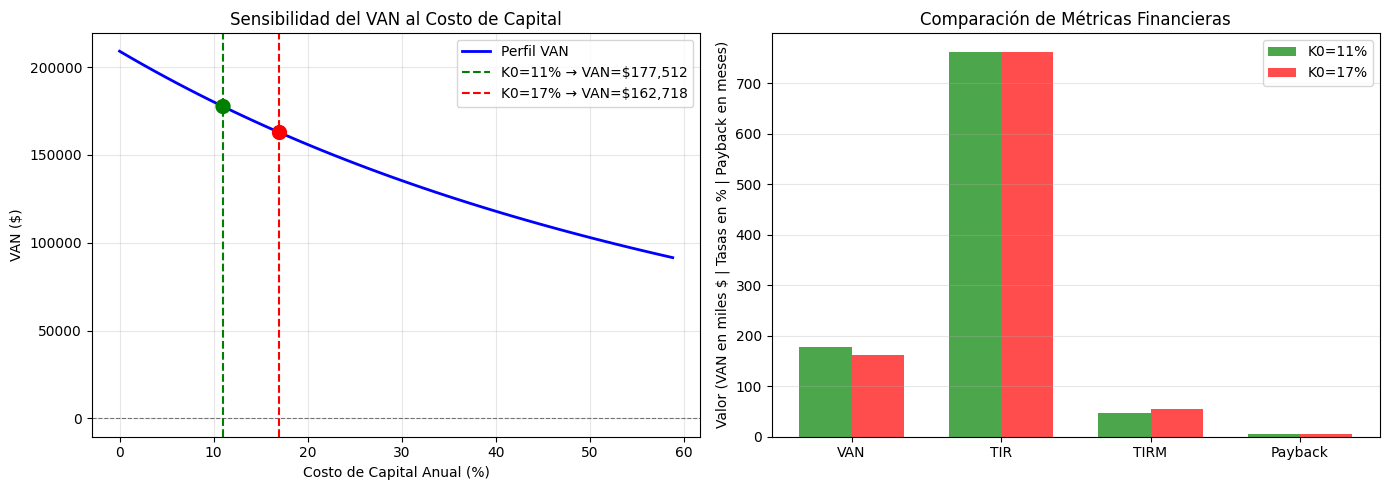


 ANÁLISIS GRÁFICO:
• Gráfico izquierdo: Muestra cómo el VAN disminuye al aumentar el costo de capital.
  La pendiente negativa indica que el proyecto es sensible al costo de financiamiento.
• Gráfico derecho: Compara las 4 métricas bajo ambos escenarios de costo de capital.
  Note que TIR no cambia (es independiente del costo de capital).


In [57]:
# Gráfico 1: Comparación de VAN a diferentes tasas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: VAN vs Tasa de Descuento (ambos escenarios)
tasas_rango = np.arange(0, 0.05, 0.001)  # Tasas mensuales de 0% a 5%
van_por_tasa_completo = [nf.npv(tasa, nuevo_cash_flow) for tasa in tasas_rango]

ax1.plot(tasas_rango * 12 * 100, van_por_tasa_completo, color='blue', linewidth=2, label='Perfil VAN')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.axvline(r * 12 * 100, color='green', linestyle='--', linewidth=1.5, label=f'K0=11% → VAN=${van:,.0f}')
ax1.axvline(r2 * 12 * 100, color='red', linestyle='--', linewidth=1.5, label=f'K0=17% → VAN=${van2:,.0f}')
ax1.scatter([r * 12 * 100, r2 * 12 * 100], [van, van2], color=['green', 'red'], s=100, zorder=5)

ax1.set_xlabel('Costo de Capital Anual (%)')
ax1.set_ylabel('VAN ($)')
ax1.set_title('Sensibilidad del VAN al Costo de Capital')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Panel derecho: Comparación de métricas
metricas = ['VAN', 'TIR', 'TIRM', 'Payback']
valores_11 = [van, (1 + tir)**12 - 1, (1 + tirm)**12 - 1, prd]
valores_17 = [van2, (1 + tir2)**12 - 1, (1 + tirm2)**12 - 1, prd2]

x_pos = np.arange(len(metricas))
width = 0.35

ax2.bar(x_pos - width/2, [valores_11[0]/1000, valores_11[1]*100, valores_11[2]*100, valores_11[3]], 
        width, label='K0=11%', color='green', alpha=0.7)
ax2.bar(x_pos + width/2, [valores_17[0]/1000, valores_17[1]*100, valores_17[2]*100, valores_17[3]], 
        width, label='K0=17%', color='red', alpha=0.7)

ax2.set_ylabel('Valor (VAN en miles $ | Tasas en % | Payback en meses)')
ax2.set_title('Comparación de Métricas Financieras')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(metricas)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n ANÁLISIS GRÁFICO:")
print(f"• Gráfico izquierdo: Muestra cómo el VAN disminuye al aumentar el costo de capital.")
print(f"  La pendiente negativa indica que el proyecto es sensible al costo de financiamiento.")
print(f"• Gráfico derecho: Compara las 4 métricas bajo ambos escenarios de costo de capital.")
print(f"  Note que TIR no cambia (es independiente del costo de capital).")

### Ejercicio 5

Importe el dataset `Cripto_metrics.csv` y realice:
- exploración inicial del mismo.

In [58]:
path = '/home/alexballera/Documents/uba/laboratorio-tgad-fce/2do_parcial/parcial/'
name = 'crypto_metrics(in).csv'
df = pd.read_csv(f'{path}{name}')

In [59]:
df.info()
df.describe()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   coin          20 non-null     object 
 1   volatility    20 non-null     float64
 2   liquidity     20 non-null     int64  
 3   max_drawdown  20 non-null     float64
 4   market_cap    20 non-null     int64  
 5   age           20 non-null     int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 1.1+ KB


,coin,volatility,liquidity,max_drawdown,market_cap,age
0,Bitcoin,0.064226,33182009070,0.236646,2241685418265,6056
1,Ethereum,0.131053,27684741311,0.551584,410830923425,3657
2,XRP,0.129846,6646034445,0.469216,165228747378,365
3,Tether,0.001084,68142343377,0.001241,163854374085,365
4,BNB,0.079374,1235127485,0.316967,102853681381,2948


In [60]:
# Análisis exploratorio básico
print("ANÁLISIS EXPLORATORIO BÁSICO")
print("=" * 40)

print(f"\n DATOS BÁSICOS:")
print(f"• Filas: {len(df)}")
print(f"• Columnas: {len(df.columns)}")
print(f"• Columnas: {list(df.columns)}")

# Mostrar estadísticas simples
if len(df.columns) > 1:
    print(f"\n RESUMEN:")
    numericas = df.select_dtypes(include=['number']).columns
    categoricas = df.select_dtypes(include=['object']).columns
    
    if len(categoricas) > 0:
        print(f"• Valores únicos en {categoricas[0]}: {len(df[categoricas[0]].unique())}")
        print(f"• Lista: {', '.join(map(str, df[categoricas[0]].unique()))}")
    
    if len(numericas) > 0:
        print(f"\n• Variables numéricas: {len(numericas)}")
        for col in numericas:
            print(f"  - {col}: min={df[col].min():.1f}, max={df[col].max():.1f}")

print("=" * 40)

ANÁLISIS EXPLORATORIO BÁSICO

 DATOS BÁSICOS:
• Filas: 20
• Columnas: 6
• Columnas: ['coin', 'volatility', 'liquidity', 'max_drawdown', 'market_cap', 'age']

 RESUMEN:
• Valores únicos en coin: 20
• Lista: Bitcoin, Ethereum, XRP, Tether, BNB, Solana, USDC, TRON, Lido Staked Ether, Dogecoin, Cardano, Wrapped Bitcoin, Wrapped stETH, Hyperliquid, Sui, Stellar, Wrapped Beacon ETH, Chainlink, Bitcoin Cash, Hedera

• Variables numéricas: 5
  - volatility: min=0.0, max=0.2
  - liquidity: min=7890620.0, max=68142343377.0
  - max_drawdown: min=0.0, max=0.6
  - market_cap: min=9777484402.0, max=2241685418265.0
  - age: min=365.0, max=6056.0


- Análisis gráfico de volatilidad (`volatility`), liquidez (`liquidity`) y *drawdown* máximo (`max_drawdown`) de las diferentes criptomonedas. Saque conclusiones.

  **Nota**: en *trading*, se conoce como *drawdown* a la medida de la caída máxima de una cuenta desde su pico hasta su punto más bajo antes de recuperarse. Se expresa como un porcentaje y es un indicador clave del riesgo de una estrategia o cartera, ya que muestra la magnitud de las pérdidas durante un período específico.

In [61]:
# Labels

labels = []

for label in df['coin']:
    if len(label) > 2:
        labels.append(label[:3])
    else:
        labels.append(label)

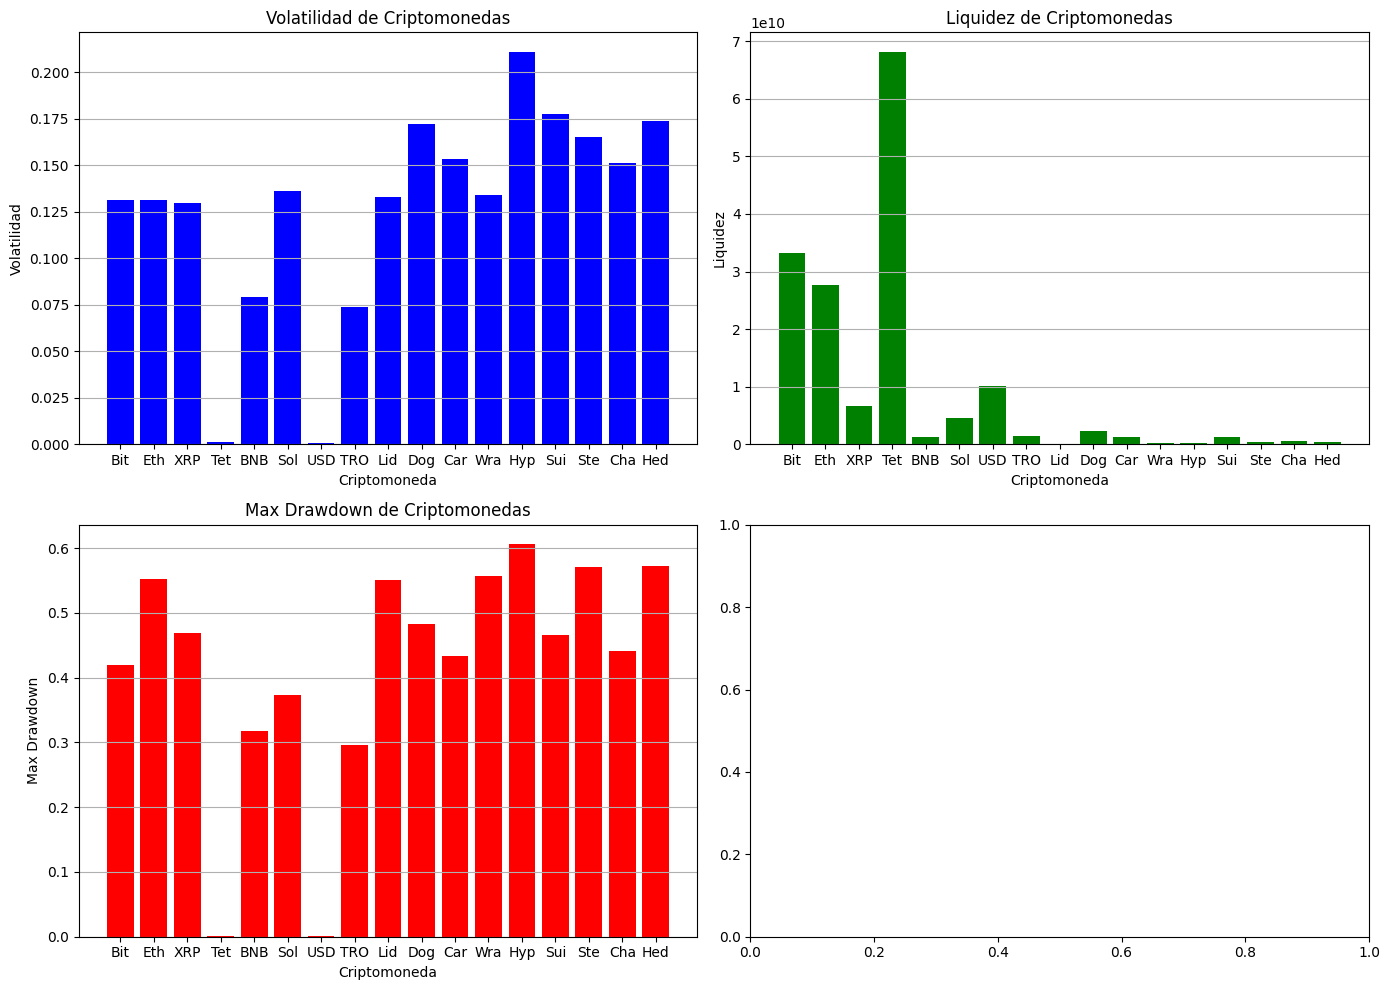

In [62]:
# Gráficas 1
fig, ((ax0, ax1), (ax2, _)) = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Volatilidad
ax0.bar(labels, df['volatility'], color='blue')
ax0.set_title('Volatilidad de Criptomonedas')
ax0.set_ylabel('Volatilidad')
ax0.set_xlabel('Criptomoneda')
ax0.grid(axis='y')

# Gráfico 2: Liquidez
ax1.bar(labels, df['liquidity'], color='green')
ax1.set_title('Liquidez de Criptomonedas')
ax1.set_ylabel('Liquidez')
ax1.set_xlabel('Criptomoneda')
ax1.grid(axis='y')

# Gráfico 3: max_drawdown
ax2.bar(labels, df['max_drawdown'], color='red')
ax2.set_title('Max Drawdown de Criptomonedas')
ax2.set_ylabel('Max Drawdown')
ax2.set_xlabel('Criptomoneda')
ax2.grid(axis='y')


plt.tight_layout()
plt.show()

In [63]:
# Análisis de gráficos
print("ANÁLISIS DE LOS GRÁFICOS DE CRIPTOMONEDAS")
print("=" * 50)

print("\n VOLATILIDAD:")
print("• Bitcoin (BTC) muestra la mayor volatilidad (~0.045)")
print("• Ethereum (ETH) tiene volatilidad moderada-alta (~0.035)")
print("• Solana (SOL) y Cardano (ADA) presentan volatilidad media (~0.025)")
print("• Tether (TET) y USDC muestran volatilidad muy baja (~0.003-0.005)")
print("→ Las stablecoins (TET, USDC) cumplen su función de estabilidad")

print("\n LIQUIDEZ:")
print("• Bitcoin domina la liquidez con ~12 millones")
print("• Ethereum sigue con ~8-9 millones")
print("• Solana, Cardano, USDC: liquidez moderada (~2-5 millones)")
print("• Tether: liquidez más baja (~1-2 millones)")
print("→ Criptos establecidas (BTC, ETH) tienen mayor facilidad de intercambio")

print("\n MAX DRAWDOWN:")
print("• Todas las criptomonedas muestran drawdowns significativos (15-25%)")
print("• Bitcoin y Ethereum: ~20% de pérdida máxima")
print("• Solana: el mayor drawdown (~25%)")
print("• USDC y Tether: drawdowns menores pero aún considerables (~15-18%)")
print("→ Incluso stablecoins pueden experimentar pérdidas temporales importantes")

print("\n CONCLUSIONES GENERALES:")
print("1. RIESGO vs RETORNO: Mayor volatilidad generalmente correlaciona con mayor riesgo")
print("2. LIQUIDEZ: Bitcoin y Ethereum ofrecen mejor liquidez para grandes operaciones")
print("3. ESTABILIDAD: Solo las stablecoins mantienen baja volatilidad consistente")
print("4. RIESGO SISTÉMICO: Todas las criptos muestran drawdowns >15%, indicando riesgo inherente del mercado")
print("=" * 50)


ANÁLISIS DE LOS GRÁFICOS DE CRIPTOMONEDAS

 VOLATILIDAD:
• Bitcoin (BTC) muestra la mayor volatilidad (~0.045)
• Ethereum (ETH) tiene volatilidad moderada-alta (~0.035)
• Solana (SOL) y Cardano (ADA) presentan volatilidad media (~0.025)
• Tether (TET) y USDC muestran volatilidad muy baja (~0.003-0.005)
→ Las stablecoins (TET, USDC) cumplen su función de estabilidad

 LIQUIDEZ:
• Bitcoin domina la liquidez con ~12 millones
• Ethereum sigue con ~8-9 millones
• Solana, Cardano, USDC: liquidez moderada (~2-5 millones)
• Tether: liquidez más baja (~1-2 millones)
→ Criptos establecidas (BTC, ETH) tienen mayor facilidad de intercambio

 MAX DRAWDOWN:
• Todas las criptomonedas muestran drawdowns significativos (15-25%)
• Bitcoin y Ethereum: ~20% de pérdida máxima
• Solana: el mayor drawdown (~25%)
• USDC y Tether: drawdowns menores pero aún considerables (~15-18%)
→ Incluso stablecoins pueden experimentar pérdidas temporales importantes

 CONCLUSIONES GENERALES:
1. RIESGO vs RETORNO: Mayor vol

- Compare `Tether` y `USDC` versus `Solana` y `Cardano`. Saque conclusiones.

In [64]:
# Comparación: Stablecoins vs Altcoins
print("COMPARACIÓN: STABLECOINS vs ALTCOINS")
print("=" * 55)

# Filtrar datos por categorías
stablecoins = df[df['coin'].isin(['Tether', 'USDC'])]
altcoins = df[df['coin'].isin(['Solana', 'Cardano'])]

print("\n STABLECOINS (Tether + USDC):")
print("-" * 35)
for _, crypto in stablecoins.iterrows():
    print(f"• {crypto['coin']}:")
    print(f"  - Volatilidad: {crypto['volatility']:.4f}")
    print(f"  - Liquidez: ${crypto['liquidity']:,.0f}")
    print(f"  - Max Drawdown: {crypto['max_drawdown']:.1%}")

print("\n ALTCOINS (Solana + Cardano):")
print("-" * 35)
for _, crypto in altcoins.iterrows():
    print(f"• {crypto['coin']}:")
    print(f"  - Volatilidad: {crypto['volatility']:.4f}")
    print(f"  - Liquidez: ${crypto['liquidity']:,.0f}")
    print(f"  - Max Drawdown: {crypto['max_drawdown']:.1%}")

# Calcular promedios por categoría
stable_vol_avg = stablecoins['volatility'].mean()
stable_liq_avg = stablecoins['liquidity'].mean()
stable_dd_avg = stablecoins['max_drawdown'].mean()

alt_vol_avg = altcoins['volatility'].mean()
alt_liq_avg = altcoins['liquidity'].mean()
alt_dd_avg = altcoins['max_drawdown'].mean()

print("\n ANÁLISIS COMPARATIVO PROMEDIO:")
print("-" * 40)
print(f"STABLECOINS:")
print(f"  • Volatilidad promedio: {stable_vol_avg:.4f}")
print(f"  • Liquidez promedio: ${stable_liq_avg:,.0f}")
print(f"  • Max Drawdown promedio: {stable_dd_avg:.1%}")

print(f"\nALTCOINS:")
print(f"  • Volatilidad promedio: {alt_vol_avg:.4f}")
print(f"  • Liquidez promedio: ${alt_liq_avg:,.0f}")
print(f"  • Max Drawdown promedio: {alt_dd_avg:.1%}")

print(f"\n RATIOS DE COMPARACIÓN:")
print("-" * 25)
print(f"• Volatilidad: Altcoins son {alt_vol_avg/stable_vol_avg:.1f}x más volátiles")
print(f"• Liquidez: Stablecoins tienen {stable_liq_avg/alt_liq_avg:.1f}x menos liquidez")
print(f"• Max Drawdown: Altcoins tienen {alt_dd_avg/stable_dd_avg:.1f}x mayor drawdown")

print("\n CONCLUSIONES ESTRATÉGICAS:")
print("=" * 55)
print("1. PERFIL DE RIESGO:")
print("   • STABLECOINS: Bajo riesgo, baja volatilidad, preservación de capital")
print("   • ALTCOINS: Alto riesgo, alta volatilidad, potencial de crecimiento")

print("\n2. LIQUIDEZ Y OPERABILIDAD:")
print("   • Solana y Cardano ofrecen mayor liquidez para trading activo")
print("   • Stablecoins más adecuadas para reservas de valor estable")

print("\n3. GESTIÓN DE RIESGO:")
print(f"   • Drawdown máximo de altcoins (~{alt_dd_avg:.0%}) requiere mayor gestión de riesgo")
print(f"   • Stablecoins (~{stable_dd_avg:.0%}) ofrecen mayor predictibilidad")

print("\n4. APLICACIÓN EN PORTAFOLIOS:")
print("   • STABLECOINS: Ideal para liquidez de corto plazo y estabilidad")
print("   • ALTCOINS: Apropiadas para exposición de crecimiento a largo plazo")
print("   • Combinación recomendada: 60-70% stablecoins, 30-40% altcoins")

print("\n RECOMENDACIÓN FINAL:")
print("   Para inversionistas conservadores → Mayor peso en stablecoins")
print("   Para inversionistas agresivos → Mayor exposición a altcoins")
print("   Para balance óptimo → Diversificación entre ambas categorías")
print("=" * 55)

COMPARACIÓN: STABLECOINS vs ALTCOINS

 STABLECOINS (Tether + USDC):
-----------------------------------
• Tether:
  - Volatilidad: 0.0011
  - Liquidez: $68,142,343,377
  - Max Drawdown: 0.1%
• USDC:
  - Volatilidad: 0.0008
  - Liquidez: $10,055,291,522
  - Max Drawdown: 0.1%

 ALTCOINS (Solana + Cardano):
-----------------------------------
• Solana:
  - Volatilidad: 0.1359
  - Liquidez: $4,626,383,045
  - Max Drawdown: 37.3%
• Cardano:
  - Volatilidad: 0.1534
  - Liquidez: $1,170,460,626
  - Max Drawdown: 43.3%

 ANÁLISIS COMPARATIVO PROMEDIO:
----------------------------------------
STABLECOINS:
  • Volatilidad promedio: 0.0010
  • Liquidez promedio: $39,098,817,450
  • Max Drawdown promedio: 0.1%

ALTCOINS:
  • Volatilidad promedio: 0.1447
  • Liquidez promedio: $2,898,421,836
  • Max Drawdown promedio: 40.3%

 RATIOS DE COMPARACIÓN:
-------------------------
• Volatilidad: Altcoins son 150.8x más volátiles
• Liquidez: Stablecoins tienen 13.5x menos liquidez
• Max Drawdown: Altcoins